--- PARÁMETROS POBLACIONALES (N=1000) ---
Media Poblacional Real (mu): 12.5401 g/dL

--- DISEÑO DE MUESTRREO (n=100, Afijación Proporcional) ---
Estrato Leve    : N_h=500, W_h=0.50, n_h=50
Estrato Moderada: N_h=300, W_h=0.30, n_h=30
Estrato Grave   : N_h=200, W_h=0.20, n_h=20

--- RESULTADOS DE LA INFERENCIA ---
Media Estratificada Estimada (y_st): 12.4430 g/dL
Error Estándar (SE): 0.1380
IC 95%: [12.1726, 12.7134]


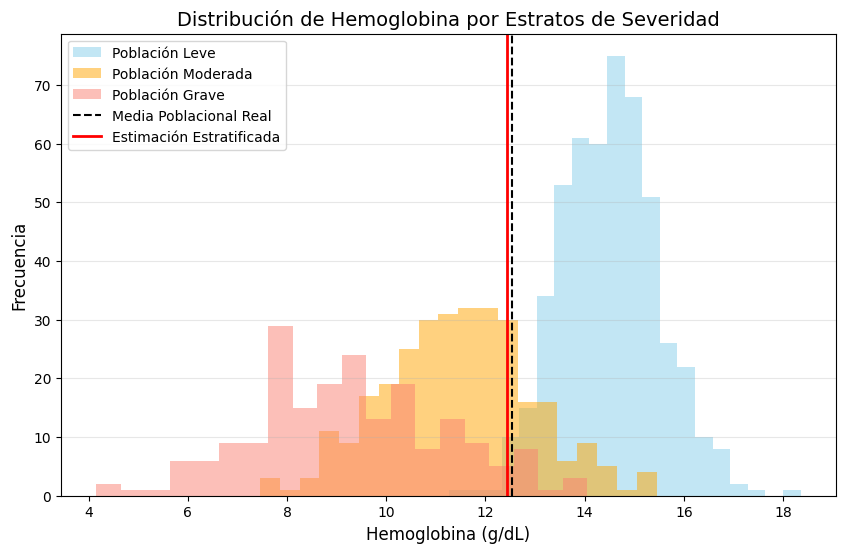

In [2]:
# muestreo estratificado
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

def generar_datos_clinicos():
    """
    Genera una población sintética de 1,000 pacientes con niveles de hemoglobina
    estratificados por severidad de la enfermedad.
    """
    np.random.seed(42)
    N = 1000
    
    # Definición de estratos y sus pesos en la población (N_h)
    # Se asume una prevalencia hospitalaria común: Leve (50%), Moderada (30%), Grave (20%)
    estratos_config = {
        'Leve': {'N_h': 500, 'mean': 14.5, 'std': 1.0},
        'Moderada': {'N_h': 300, 'mean': 11.5, 'std': 1.5},
        'Grave': {'N_h': 200, 'mean': 9.0, 'std': 2.0}
    }
    
    datos = []
    for severidad, config in estratos_config.items():
        # Generación de valores siguiendo una distribución normal N(mu, sigma^2)
        hb_vals = np.random.normal(config['mean'], config['std'], config['N_h'])
        for val in hb_vals:
            datos.append({'Severidad': severidad, 'Hemoglobina': val})
            
    return pd.DataFrame(datos), estratos_config

def analisis_estratificado():
    """
    Ejecuta el flujo de muestreo estratificado y cálculo de estimadores.
    """
    df_poblacion, config_poblacion = generar_datos_clinicos()
    N = len(df_poblacion)
    
    # 1. Parámetros Poblacionales Reales (Gold Standard)
    media_poblacional_real = df_poblacion['Hemoglobina'].mean()
    print(f"--- PARÁMETROS POBLACIONALES (N={N}) ---")
    print(f"Media Poblacional Real (mu): {media_poblacional_real:.4f} g/dL\n")

    # 2. Diseño del Muestreo Estratificado
    # Deseamos una muestra total n = 100 utilizando Afijación Proporcional
    n_total = 100
    
    # n_h = n * (N_h / N)
    print(f"--- DISEÑO DE MUESTRREO (n={n_total}, Afijación Proporcional) ---")
    muestras_estratos = {}
    
    for severidad, config in config_poblacion.items():
        N_h = config['N_h']
        W_h = N_h / N  # Peso del estrato
        n_h = int(n_total * W_h) # Tamaño de muestra del estrato h
        
        # Selección aleatoria simple dentro del estrato
        estrato_data = df_poblacion[df_poblacion['Severidad'] == severidad]
        muestras_estratos[severidad] = estrato_data.sample(n=n_h, random_state=42)
        
        print(f"Estrato {severidad:8}: N_h={N_h}, W_h={W_h:.2f}, n_h={n_h}")

    # 3. Estimación de la Media Estratificada (y_st)
    # Formula: y_st = sum(W_h * y_bar_h)
    df_muestra_total = pd.concat(muestras_estratos.values())
    
    estimaciones_h = []
    for severidad, muestra_h in muestras_estratos.items():
        y_bar_h = muestra_h['Hemoglobina'].mean()
        s_h_sq = muestra_h['Hemoglobina'].var()
        W_h = config_poblacion[severidad]['N_h'] / N
        estimaciones_h.append({
            'Severidad': severidad,
            'y_bar_h': y_bar_h,
            's_h_sq': s_h_sq,
            'W_h': W_h,
            'n_h': len(muestra_h)
        })

    df_est = pd.DataFrame(estimaciones_h)
    media_estratificada = (df_est['W_h'] * df_est['y_bar_h']).sum()

    # 4. Cálculo de la Varianza del Estimador
    # Var(y_st) = sum [ W_h^2 * (1 - f_h) * (s_h^2 / n_h) ]
    # f_h = n_h / N_h (fracción de muestreo)
    varianza_y_st = 0
    for idx, row in df_est.iterrows():
        N_h = config_poblacion[row['Severidad']]['N_h']
        f_h = row['n_h'] / N_h
        termino = (row['W_h']**2) * (1 - f_h) * (row['s_h_sq'] / row['n_h'])
        varianza_y_st += termino
    
    error_estandar = np.sqrt(varianza_y_st)
    
    # Intervalo de Confianza 95%
    z = stats.norm.ppf(0.975)
    ic_inf = media_estratificada - z * error_estandar
    ic_sup = media_estratificada + z * error_estandar

    print(f"\n--- RESULTADOS DE LA INFERENCIA ---")
    print(f"Media Estratificada Estimada (y_st): {media_estratificada:.4f} g/dL")
    print(f"Error Estándar (SE): {error_estandar:.4f}")
    print(f"IC 95%: [{ic_inf:.4f}, {ic_sup:.4f}]")
    
    # 5. Visualización
    plt.figure(figsize=(10, 6))
    colors = {'Leve': 'skyblue', 'Moderada': 'orange', 'Grave': 'salmon'}
    
    for severidad in config_poblacion.keys():
        subset = df_poblacion[df_poblacion['Severidad'] == severidad]
        plt.hist(subset['Hemoglobina'], bins=20, alpha=0.5, 
                 label=f'Población {severidad}', color=colors[severidad])
    
    plt.axvline(media_poblacional_real, color='black', linestyle='--', label='Media Poblacional Real')
    plt.axvline(media_estratificada, color='red', linewidth=2, label='Estimación Estratificada')
    
    plt.title('Distribución de Hemoglobina por Estratos de Severidad', fontsize=14)
    plt.xlabel('Hemoglobina (g/dL)', fontsize=12)
    plt.ylabel('Frecuencia', fontsize=12)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

if __name__ == "__main__":
    analisis_estratificado()

In [1]:
import pandas as pd
import numpy as np
import random

# 1. Simulación del Marco Muestral (N = 1000 pacientes)
# Se genera una variable de interés: Presión Arterial Sistólica (PAS)
# Asumimos una distribución normal típica en adultos: media=120, ds=15 [9, 10]
np.random.seed(42)
N = 1000
n_muestra = 100  # Tamaño deseado para el análisis

pacientes_id = np.arange(1, N + 1)
pas_valores = np.random.normal(loc=120, scale=15, size=N).round(1)

# Creación del DataFrame (Base de datos hospitalaria)
df_hospital = pd.DataFrame({
    'Paciente_ID': pacientes_id,
    'PAS_mmHg': pas_valores
})

# 2. Cálculo de parámetros para Muestreo Sistemático
k = N // n_muestra  # Intervalo de muestreo [1, 2]

# 3. Selección del punto de arranque aleatorio (m) entre 1 y k
arranque_aleatorio = random.randint(0, k - 1) # Índice 0 a k-1 en Python

# 4. Extracción sistemática de la muestra
# Seleccionamos cada k-ésimo paciente partiendo desde el arranque
indices_seleccionados = np.arange(arranque_aleatorio, N, step=k)
muestra_sistematica = df_hospital.iloc[indices_seleccionados]

# Visualización de resultados
print(f"--- Parámetros del Muestreo ---")
print(f"Población (N): {N}")
print(f"Muestra deseada (n): {n_muestra}")
print(f"Intervalo (k): {k}")
print(f"Punto de arranque aleatorio: {arranque_aleatorio + 1}")
print(f"\n--- Primeros registros de la muestra ---")
print(muestra_sistematica.head(10))

# Validación científica: Comparación de medias
media_poblacional = df_hospital['PAS_mmHg'].mean()
media_muestral = muestra_sistematica['PAS_mmHg'].mean()

print(f"\nMedia PAS Poblacional: {media_poblacional:.2f} mmHg")
print(f"Media PAS Muestral: {media_muestral:.2f} mmHg")

--- Parámetros del Muestreo ---
Población (N): 1000
Muestra deseada (n): 100
Intervalo (k): 10
Punto de arranque aleatorio: 4

--- Primeros registros de la muestra ---
    Paciente_ID  PAS_mmHg
3             4     142.8
13           14      91.3
23           24      98.6
33           34     104.1
43           44     115.5
53           54     129.2
63           64     102.1
73           74     143.5
83           84     112.2
93           94     115.1

Media PAS Poblacional: 120.29 mmHg
Media PAS Muestral: 121.64 mmHg
